In [ ]:
!pip -q install imbalanced-learn
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Setup complete.")

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
dataset = pd.read_excel('/content/drive/MyDrive/oral_cancer_prediction_dataset(1).csv.xlsx')

In [ ]:
KNN

In [6]:
mode = "demo"
mode

'demo'

In [7]:
if mode == "demo":

    n_samples = 1200
    age = np.random.normal(52, 10, size=n_samples).clip(18, 85)
    gender = np.random.binomial(1, 0.55, size=n_samples)
    smoking = np.random.gamma(shape=2., scale=2., size=n_samples)
    alcohol = np.random.gamma(shape=1.8, scale=2.5, size=n_samples)
    betel_nut = np.random.binomial(1, 0.35, size=n_samples)
    lesion_size = np.abs(np.random.normal(2.2, 0.9, size=n_samples))
    path_risk = np.random.normal(0.0, 1.0, size=n_samples)


    logit = (
        0.02*(age-50) +
        0.6*smoking +
        0.5*alcohol +
        0.9*betel_nut +
        0.4*lesion_size +
        0.8*gender +
        0.7*path_risk
    )
    prob = 1/(1+np.exp(-logit + 3.0))
    y = (np.random.rand(n_samples) < prob).astype(int)

    df = pd.DataFrame({
        "ID": np.arange(1, n_samples+1),
        "Country": np.random.choice(["USA", "Canada", "UK", "Germany"], size=n_samples),
        "Age": age.round(1),
        "Gender_Male": gender,
        "SmokingScore": smoking.round(3),
        "AlcoholScore": alcohol.round(3),
        "BetelNutUser": betel_nut,
        "LesionSize_cm": lesion_size.round(2),
        "PathRiskScore": path_risk.round(3),
        "Label": y
    })

    print("🧪 Synthetic demo dataset created.")
    display(df.head())
    print("\n📐 Shape:", df.shape)

🧪 Synthetic demo dataset created.


,ID,Country,Age,Gender_Male,SmokingScore,AlcoholScore,BetelNutUser,LesionSize_cm,PathRiskScore,Label
0,1,UK,57.0,1,4.792,6.289,1,3.31,-1.121,1
1,2,Canada,50.6,0,7.229,5.765,0,2.61,1.380,1
2,3,UK,58.5,0,1.647,6.136,0,2.43,2.037,1
3,4,USA,67.2,0,1.026,4.569,1,2.93,0.147,1
4,5,Canada,49.7,0,6.588,8.608,0,1.96,0.511,1



📐 Shape: (1200, 10)


In [8]:
possible_targets = ["Label", "label", "TARGET", "target", "Outcome", "Cancer", "cancer"]
target_col = None
for c in possible_targets:
    if c in df.columns:
        target_col = c
        break

if target_col is None:
    raise ValueError("❌ Could not find target column. Please rename your target column to 'Label' (0/1) or update 'possible_targets' list.")


if df[target_col].dtype == object:
    lower_map = df[target_col].astype(str).str.lower()

    if set(lower_map.unique()) <= {"yes","no","cancer","nocancer","positive","negative"}:
        map_dict = {"yes":1,"no":0,"cancer":1,"nocancer":0,"positive":1,"negative":0}
        df[target_col] = lower_map.map(map_dict).astype(int)


df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

# Drop the 'ID' and 'Country' columns before splitting
X = df.drop(columns=['ID', 'Country', target_col])
y = df[target_col].astype(int)

print(f"🎯 Target column: {target_col}")
print("✅ Cleaned shape:", df.shape)
print("\nClass balance:")
print(y.value_counts(normalize=True).rename({0:"Class 0 (NoCancer)",1:"Class 1 (Cancer)"}) * 100)

🎯 Target column: Label
✅ Cleaned shape: (1200, 10)

Class balance:
Label
Class 1 (Cancer)      85.666667
Class 0 (NoCancer)    14.333333
Name: proportion, dtype: float64


In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

print("Train:", X_train.shape, "Valid:", X_valid.shape, "Test:", X_test.shape)

Train: (840, 7) Valid: (180, 7) Test: (180, 7)


In [10]:
knn = KNeighborsClassifier()

pipe = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("knn", knn)
])


param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],
    "knn__metric": ["minkowski"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("🏆 Best params:", grid.best_params_)
print("🏆 Best CV F1:", grid.best_score_)
best_model = grid.best_estimator_

# Validation set performance (hold-out)
y_pred_val = best_model.predict(X_valid)
proba_val = getattr(best_model, "predict_proba", None)
y_prob_val = proba_val(X_valid)[:,1] if proba_val else None

print("\n🔎 Validation metrics:")
print("Acc:", accuracy_score(y_valid, y_pred_val))
print("Precision:", precision_score(y_valid, y_pred_val, zero_division=0))
print("Recall:", recall_score(y_valid, y_pred_val))
print("F1:", f1_score(y_valid, y_pred_val))
if y_prob_val is not None and len(np.unique(y_valid)) == 2:
    print("ROC-AUC:", roc_auc_score(y_valid, y_prob_val))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
🏆 Best params: {'knn__metric': 'minkowski', 'knn__n_neighbors': 5, 'knn__p': 2, 'knn__weights': 'uniform'}
🏆 Best CV F1: 0.8602364774012601

🔎 Validation metrics:
Acc: 0.7277777777777777
Precision: 0.9069767441860465
Recall: 0.7597402597402597
F1: 0.8268551236749117
ROC-AUC: 0.6871878121878121


In [11]:
y_pred = best_model.predict(X_test)
proba = getattr(best_model, "predict_proba", None)
y_prob = proba(X_test)[:,1] if proba else None

print("🧪 Test metrics:")
print("Acc:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
if y_prob is not None and len(np.unique(y_test)) == 2:
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

🧪 Test metrics:
Acc: 0.7444444444444445
Precision: 0.9736842105263158
Recall: 0.7207792207792207
F1: 0.8283582089552238
ROC-AUC: 0.8622627372627373


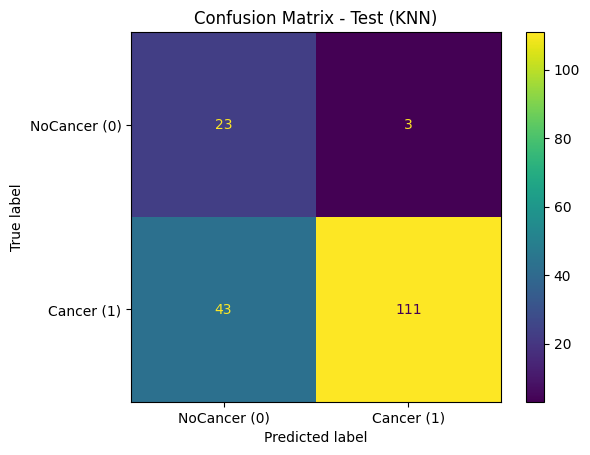

In [12]:
cm = confusion_matrix(y_test, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NoCancer (0)","Cancer (1)"])
disp.plot(values_format='d')
plt.title("Confusion Matrix - Test (KNN)")
plt.show()

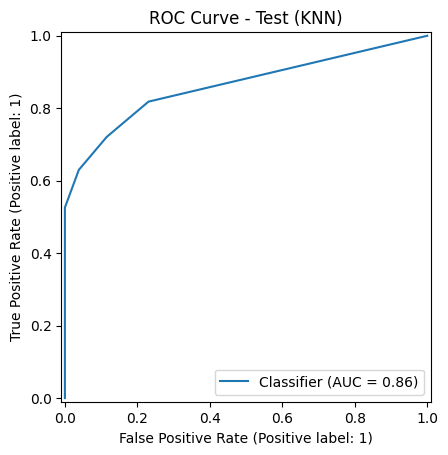

In [13]:
if y_prob is not None and len(np.unique(y_test)) == 2:
    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title("ROC Curve - Test (KNN)")
    plt.show()

In [14]:
dataset.shape

(84922, 25)

In [15]:
dataset.head(5)

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Difficulty Swallowing,White or Red Patches in Mouth,Tumor Size (cm),Cancer Stage,Treatment Type,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis)
0,1,Italy,36,Female,Yes,Yes,Yes,No,No,Yes,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,No,No
1,2,Japan,64,Male,Yes,Yes,Yes,No,Yes,Yes,...,No,No,1.782186,1,No Treatment,83.340103,77772.50,177,No,Yes
2,3,UK,37,Female,No,Yes,No,No,Yes,Yes,...,No,Yes,3.523895,2,Surgery,63.222871,101164.50,130,Yes,Yes
3,4,Sri Lanka,55,Male,Yes,Yes,No,Yes,No,Yes,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,Yes,No
4,5,South Africa,68,Male,No,No,No,No,No,Yes,...,No,No,2.834789,3,No Treatment,44.293199,45354.75,52,No,Yes


In [16]:
dataset.drop(columns = ['ID','Country'],inplace=True)

In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [18]:
scaler = StandardScaler()
# Select only the columns that are not boolean for scaling
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
dataset.shape

(84922, 23)

In [20]:
dataset['Gender'].value_counts()

,count
Gender,
Male,60351
Female,24571


In [21]:
dataset['Age'].value_counts()

,count
Age,
55,3415
56,3397
53,3352
54,3341
52,3247
...,...
16,2
96,1
91,1


1.4 Encode Categorical Data–

1.One-hot encoding 2.Label encoding 3.Ordinal encoding and more

In [22]:
categorical_cols = ['Tobacco Use', 'Alcohol Consumption', 'HPV Infection', 'Betel Quid Use',
                    'Chronic Sun Exposure', 'Poor Oral Hygiene', 'Diet (Fruits & Vegetables Intake)',
                    'Family History of Cancer', 'Compromised Immune System', 'Oral Lesions',
                    'Difficulty Swallowing', 'White or Red Patches in Mouth', 'Early Diagnosis',
                    'Unexplained Bleeding', 'Treatment Type', 'Oral Cancer (Diagnosis)'] # Include remaining categorical columns

df = pd.get_dummies(dataset,columns=['Age','Gender'] + categorical_cols,drop_first= True)

In [23]:
df

,Tumor Size (cm),Cancer Stage,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Age_16,Age_17,Age_18,Age_19,Age_20,...,Oral Lesions_Yes,Difficulty Swallowing_Yes,White or Red Patches in Mouth_Yes,Early Diagnosis_Yes,Unexplained Bleeding_Yes,Treatment Type_No Treatment,Treatment Type_Radiation,Treatment Type_Surgery,Treatment Type_Targeted Therapy,Oral Cancer (Diagnosis)_Yes
0,0.000000,0,100.000000,0.00,0,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,1.782186,1,83.340103,77772.50,177,False,False,False,False,False,...,False,False,False,False,True,True,False,False,False,True
2,3.523895,2,63.222871,101164.50,130,False,False,False,False,False,...,False,False,True,True,False,False,False,True,False,True
3,0.000000,0,100.000000,0.00,0,False,False,False,False,False,...,True,False,False,True,False,True,False,False,False,False
4,2.834789,3,44.293199,45354.75,52,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84917,0.000000,0,100.000000,0.00,0,False,False,False,False,False,...,False,False,True,True,False,True,False,False,False,False
84918,0.000000,0,100.000000,0.00,0,False,False,False,False,False,...,False,True,True,True,False,True,False,False,False,False
84919,4.777394,1,85.633426,81352.50,90,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
84920,0.000000,0,100.000000,0.00,0,False,False,False,False,False,...,True,True,False,True,False,True,False,False,False,False


1.4 Split Dataset into X and Y

In [24]:
X = df.drop(columns=['Oral Cancer (Diagnosis)_Yes']) # Drop the one-hot encoded target column
y = df['Oral Cancer (Diagnosis)_Yes'].values # Use the one-hot encoded target column for y

1.5 Split the X and Y Dataset into the Training set and Test set

In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

1.6 Perform Feature Scaling
MinMaxScaler scales the data to a fixed range, typically between 0 and 1. On the other hand, StandardScaler rescales the data to have a mean of 0 and a standard deviation of 1. This results in a distribution with zero mean and unit variance."

In [26]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
Ann

2.1 .1 Import the Keras libraries and packages

In [31]:
import keras
from keras.models import Sequential
from keras.layers import Dense

2.2 Initialize the Artificial Neural Network

In [32]:
classifier1 = Sequential()

2.3 Add the input layer and the first hidden layer

In [33]:
classifier1.add(Dense(3, kernel_initializer = 'uniform', activation = 'relu', input_dim = X_train.shape[1]))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2.4 Add the second hidden layer

In [34]:
classifier1.add(Dense(3, kernel_initializer = 'uniform', activation = 'relu'))

2.5 Add the output layer

In [35]:
classifier1.add(Dense(1, kernel_initializer = 'uniform', activation = 'sigmoid'))

3.Train the ANN 3.1 Compile the ANN

In [36]:
from tensorflow.keras.optimizers import Adam

#optimizer = Adam(learning_rate=0.01)  # you can set your desired learning rate here
classifier1.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [37]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss',   # Monitor validation loss
                               patience=10,          # Number of epochs with no improvement before stopping
                               restore_best_weights=True,  # Restore the best weights after stopping
                               verbose=1)

3.2 Fit the ANN to the Training set

Define the model

In [38]:
classifier1 = Sequential()
classifier1.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))  # <-- now 107 features automatically
classifier1.add(Dense(8, activation='relu'))
classifier1.add(Dense(1, activation='sigmoid'))

Compile the model

In [ ]:
classifier1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Add early stopping

In [39]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

Dynamically set the input size to the number of features

In [40]:
input_dim=X_train.shape[1]

Train the model

In [47]:
# Compile the model
classifier1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = classifier1.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8963 - loss: 0.2354 - val_accuracy: 0.9995 - val_loss: 0.0038
Epoch 2/100
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9998 - loss: 0.0026 - val_accuracy: 0.9998 - val_loss: 7.3504e-04
Epoch 3/100
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9999 - loss: 4.6526e-04 - val_accuracy: 0.9999 - val_loss: 8.1784e-04
Epoch 4/100
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 1.0000 - loss: 3.4378e-04 - val_accuracy: 0.9999 - val_loss: 3.1269e-04
Epoch 5/100
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9999 - loss: 4.1119e-04 - val_accuracy: 0.9999 - val_loss: 3.6376e-04
Epoch 6/100
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9999 - loss: 4.0201e-04 - val_accuracy: 0.9999 - val_loss: 1.4595e-04
Epoch 7/100
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 1.0000 - loss: 9.4971e-05 - val_accuracy: 1.0000 - val_loss: 5.0226e-05
Epoch 8/100
1062/1062 ━━━━━━━━━━━━━━━━━

Basic Dense Layer Formula

For a Dense (fully connected) layer, the number of parameters is:

Parameters=(Input units×Output units)+Output units (bias)

In [44]:
classifier1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,873 (7.32 KB)

 Trainable params: 1,873 (7.32 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
loss, accuracy = classifier1.evaluate(X_test, y_test)
print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')

531/531 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 1.0000 - loss: 4.8206e-08
Test Loss: 1.228823691690195e-07
Test Accuracy: 1.0


Plot training history (loss and accuracy)
#Plot the training and validation loss over epochs

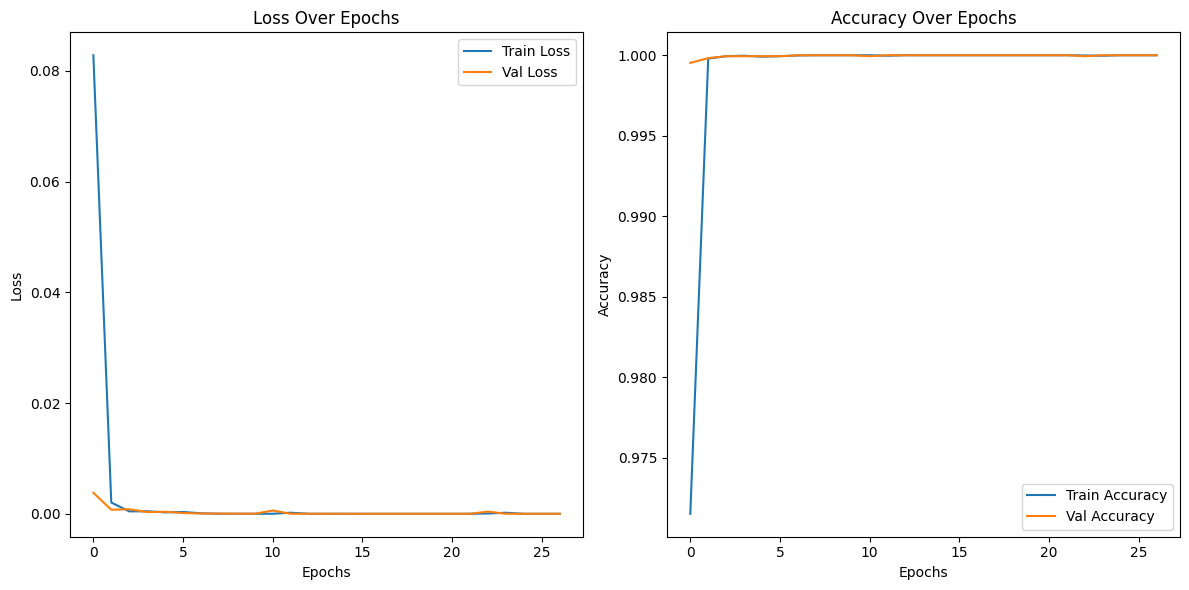

In [49]:
plt.figure(figsize=(12, 6))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Predict the Test Set Results

In [50]:
y_pred = classifier1.predict(X_test)

531/531 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  


In [51]:
y_pred

array([[3.1882921e-10],
       [1.0000000e+00],
       [1.0000000e+00],
       ...,
       [6.3460216e-11],
       [1.0000000e+00],
       [1.0000000e+00]], dtype=float32)

In [52]:
y_pred = (y_pred > 0.5)
y_pred

array([[False],
       [ True],
       [ True],
       ...,
       [False],
       [ True],
       [ True]])

5.Make the Confusion Matrix

In [53]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print("\n")
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)
print("\n")

report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

Confusion Matrix:
[[8488    0]
 [   0 8497]]


Accuracy Score: 1.0


Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      8488
        True       1.00      1.00      1.00      8497

    accuracy                           1.00     16985
   macro avg       1.00      1.00      1.00     16985
weighted avg       1.00      1.00      1.00     16985



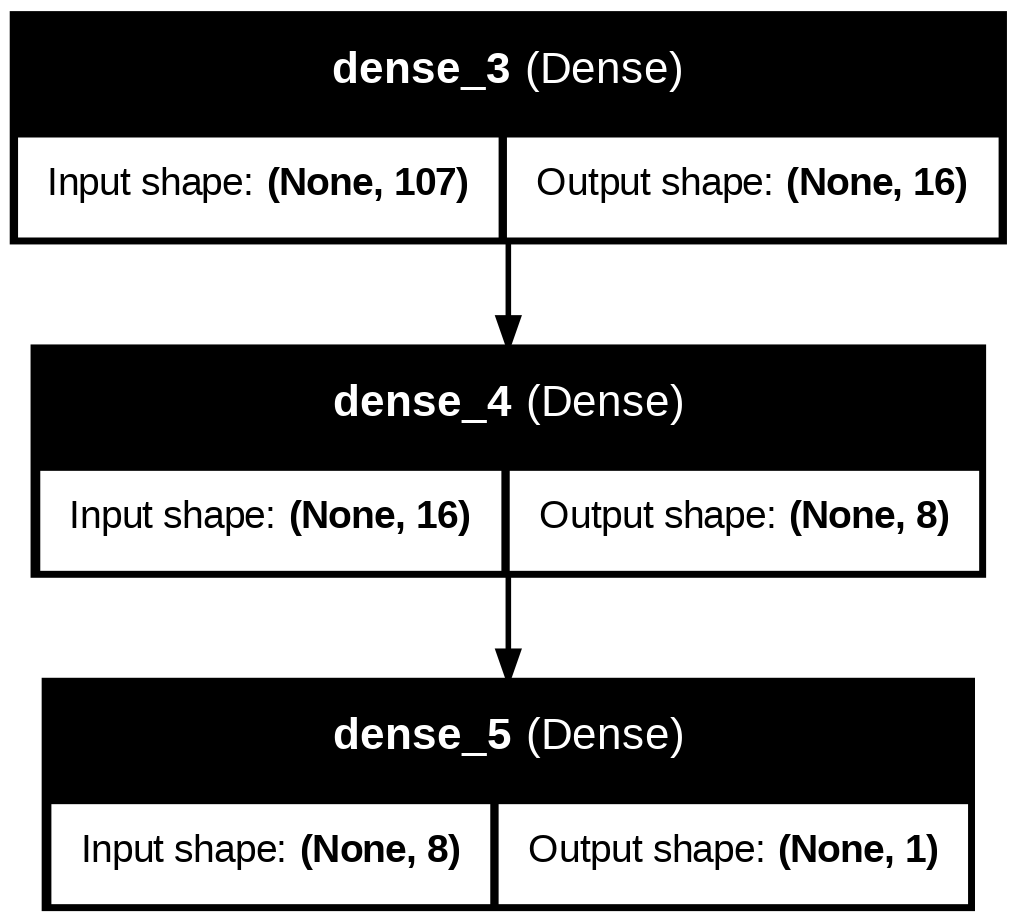

In [54]:
from tensorflow import keras
from tensorflow.keras.utils import plot_model

# Generate the visualization of the model's architecture
plot_model(classifier1, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

from IPython.display import Image
Image('model_architecture.png')


Install necessary libraries


Import libraries


In [55]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import os
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import cv2

import kagglehub


 Download latest version


In [56]:
path = kagglehub.dataset_download("shivam17299/oral-cancer-lips-and-tongue-images")


Image preprocessing


In [57]:
img_height, img_width = 128, 128
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
)

train_generator = train_datagen.flow_from_directory(
    path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=True
)


Found 105 images belonging to 1 classes.
Found 26 images belonging to 1 classes.


Build the CNN model


In [58]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification: cancer vs normal
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile the model


In [59]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Train the model



In [60]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9664 - loss: 0.2152 - val_accuracy: 1.0000 - val_loss: 7.7829e-12
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 1.0000 - loss: 1.4990e-11 - val_accuracy: 1.0000 - val_loss: 9.1730e-28
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 1.0000 - loss: 4.8808e-18 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accurac

Plot accuracy and loss


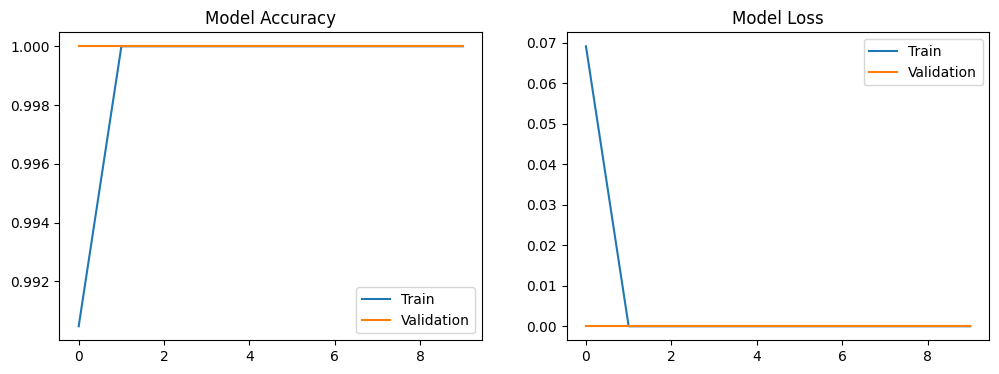

In [61]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.legend()

plt.show()


Evaluate the model


In [62]:
val_generator.reset()
preds = model.predict(val_generator)
y_pred = (preds > 0.5).astype(int)
y_true = val_generator.classes

print("Classification Report:")
print(classification_report(y_true, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 858ms/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26

    accuracy                           1.00        26
   macro avg       1.00      1.00      1.00        26
weighted avg       1.00      1.00      1.00        26

Confusion Matrix:
[[26]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Test on a single image

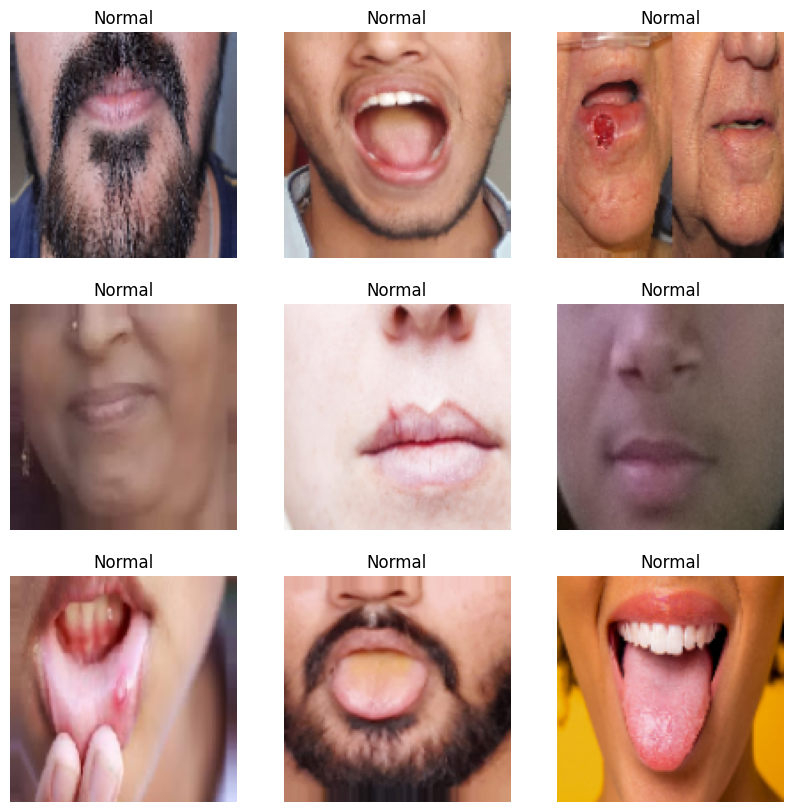

In [63]:
images, labels = next(train_generator)

plt.figure(figsize=(10, 10))
for i in range(9):  # show first 9 images
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title("Cancer" if labels[i] == 1 else "Normal")
    plt.axis("off")
plt.show()

 Get some validation images

In [64]:
val_images, val_labels = next(val_generator)


Predict

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step


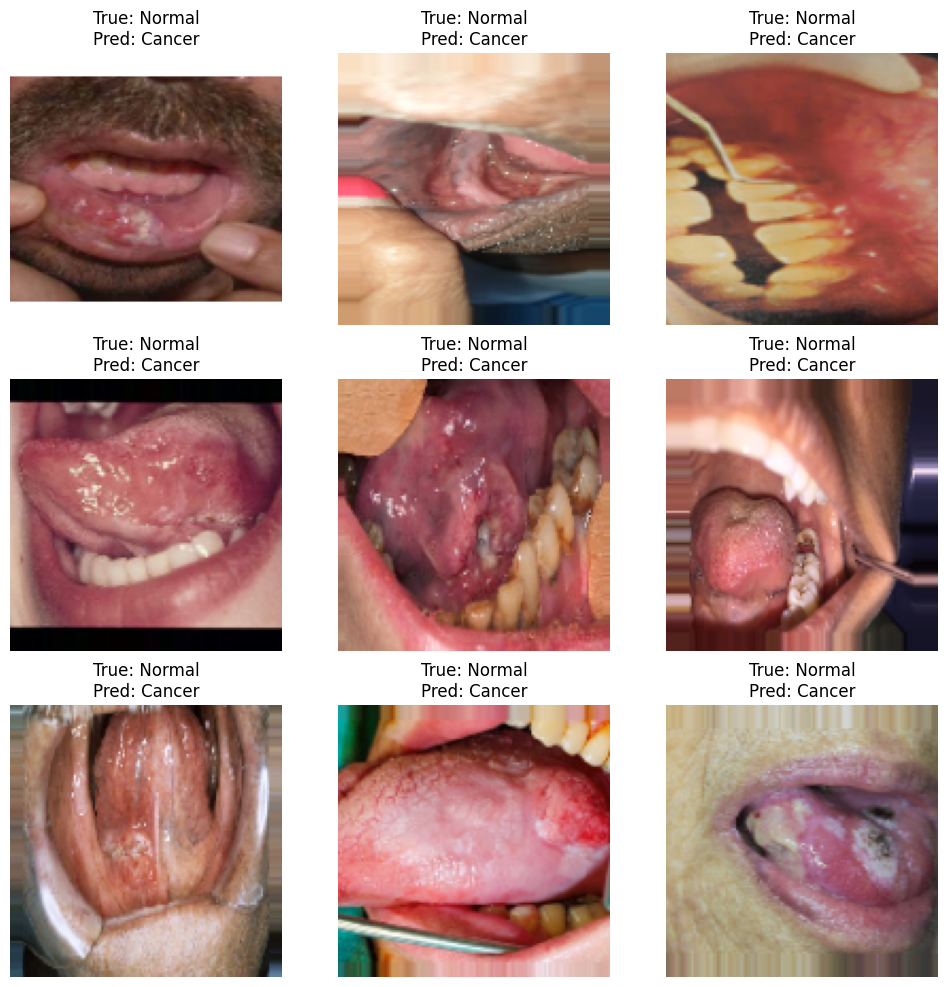

In [65]:
preds = model.predict(val_images)
pred_classes = (preds > 0.5).astype(int)

plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(val_images[i])
    true_label = "Cancer" if val_labels[i] == 1 else "Normal"
    pred_label = "Cancer" if pred_classes[i] == 0 else "Normal"
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")
plt.show()